Data & Lib

In [45]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# 1. Thống kê mô tả và đặc trưng

1.

In [46]:
print(df.head())
print('Số dòng: ', df.shape[0])
print('Số cột: ', df.shape[1])
print(df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Số dòng:  150
Số cột:  5
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


2.

In [47]:
result = dict()

for col in df.select_dtypes(include = [np.number]):
    value = df[col]
    q1 = np.quantile(value, 0.25, axis = 0)
    q3 = np.quantile(value, 0.75, axis = 0)
    result[col] = {
        'mean' : pd.Series(value).mean(),
        'median' : pd.Series(value).median(),
        'mode' : pd.Series(value).mode().iloc[0], 
        'var' : value.var(), 
        'std' : value.std(), 
        'min' : value.min(), 
        'max' : value.max(), 
        'Q1' : q1,
        'Q3' : q3,
        'IQR' : q3 - q1
    }
    
result = pd.DataFrame(result)
print(result)

        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
median      5.800000     3.000000      4.350000     1.300000
mode        5.000000     3.000000      1.400000     0.200000
var         0.685694     0.189979      3.116278     0.581006
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
max         7.900000     4.400000      6.900000     2.500000
Q1          5.100000     2.800000      1.600000     0.300000
Q3          6.400000     3.300000      5.100000     1.800000
IQR         1.300000     0.500000      3.500000     1.500000


3.

In [48]:
result = {
    'mean' : df.groupby('species').mean(numeric_only = True),
    'std': df.groupby('species').std(numeric_only = True)
}
print('mean \n', result['mean'])
print('std \n', result['std'])

mean 
             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
std 
             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


- Kích thước của cánh hoa (petal_length, petal_width): Setosa có cánh hoa nhỏ nhất (1.462, 0.246), versicolor và virginica thì lớn hơn đáng kể.
- Đài hoa(sepal_length, sepal_width): Đài hoa của setosa ngắn hơn so với hai loại còn lại rộng hơn về bề ngang.
- Độ phân tán kích thước: Nếu dự theo sepal thì khá khó để thấy được sự khác biện cụ thể, do kích thước trung bình và độ phân tán không chênh lệch đáng kể. Nhìn vàl petal có thể thấy kích thước cánh hoa  còn lại và độ phân tán kích thước nhỏ của setosa nhỏ hơn hẳn hai loại.
-> Vậy setosa có điểm khác biệt rõ nhất

# 2. Phân phối xác suất

1. Vẽ histogram và KDE

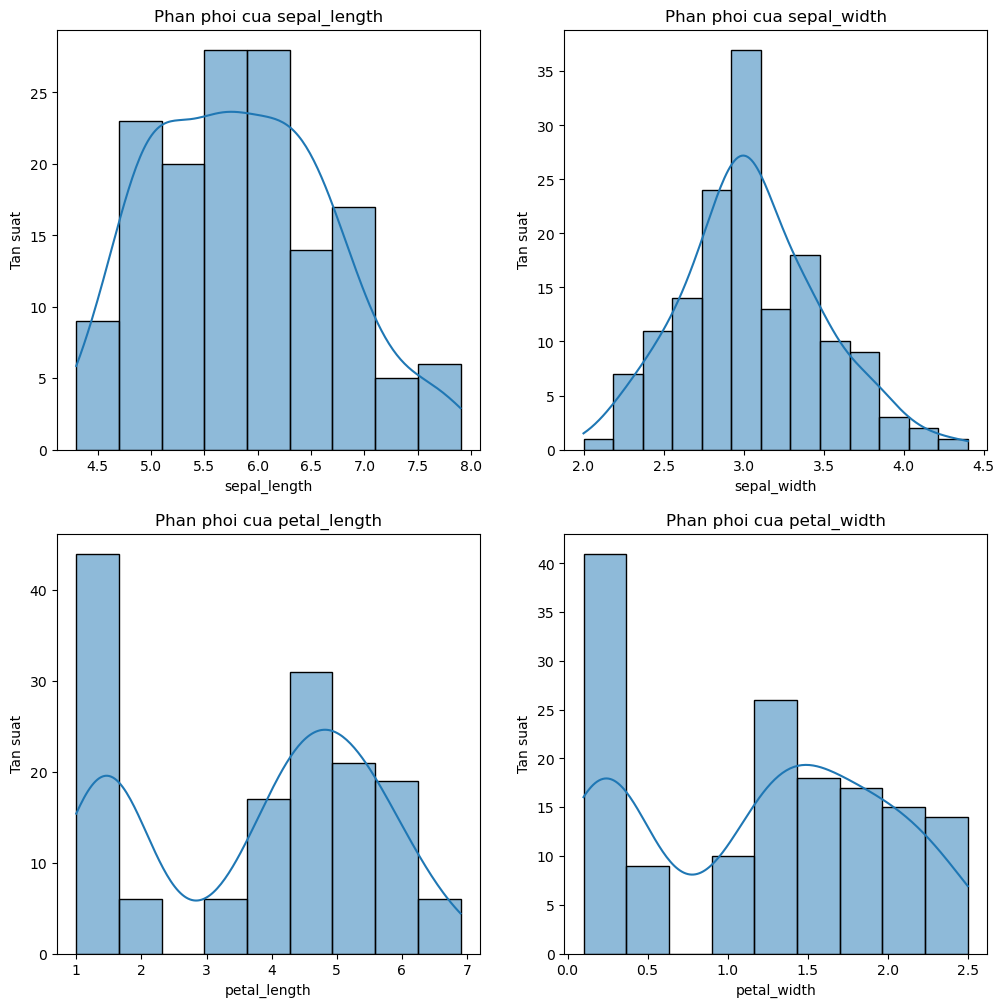

In [49]:
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flatten()
# sns.histplot?
for i, col in enumerate(df.select_dtypes(include = ['number']).columns):
    sns.histplot(data = df, x = col, kde = True, ax = ax[i])
    ax[i].set_title(f'Phan phoi cua {col}')
    ax[i].set_ylabel('Tan suat')

Nhận xét: 
- Sepal_length: 
    - Biểu đồ có hơi bị lệch phải và không có đỉnh trung tâm thật sự, gần với phân phối chuẩn.
    - Dải dữ liệu rộng và có một vùng khá bằng ở đỉnh tức đài hoa có các chiều dài đặc trưng không giống nhau.
- Sepal_width:
    - Biểu đồ có dạng hình chuông hơi lệch phải nhẹ nhẹ, có một đỉnh. 
    - Giá trị đặc trưng trong khoảng 3.0 và giảm đều về hai bên.
- Petal_length:
    - Biểu đồ có hai đỉnh, có một nhóm tập dữ liệu nằm lệch hẳn về phía bên trái.
    -> Nhiều tập đối tượng mang đặc trưng khác nhau trong dữ liệu.
- Petal_width: 
    - Biều đồ có hai đỉnh, có một nhóm tập dữ liệu nằm lệch hẳn về phái bên trái.
    -> Nhiều tập đối tượng mang đặc trưng khác nhau trong dữ liệu.    

2.

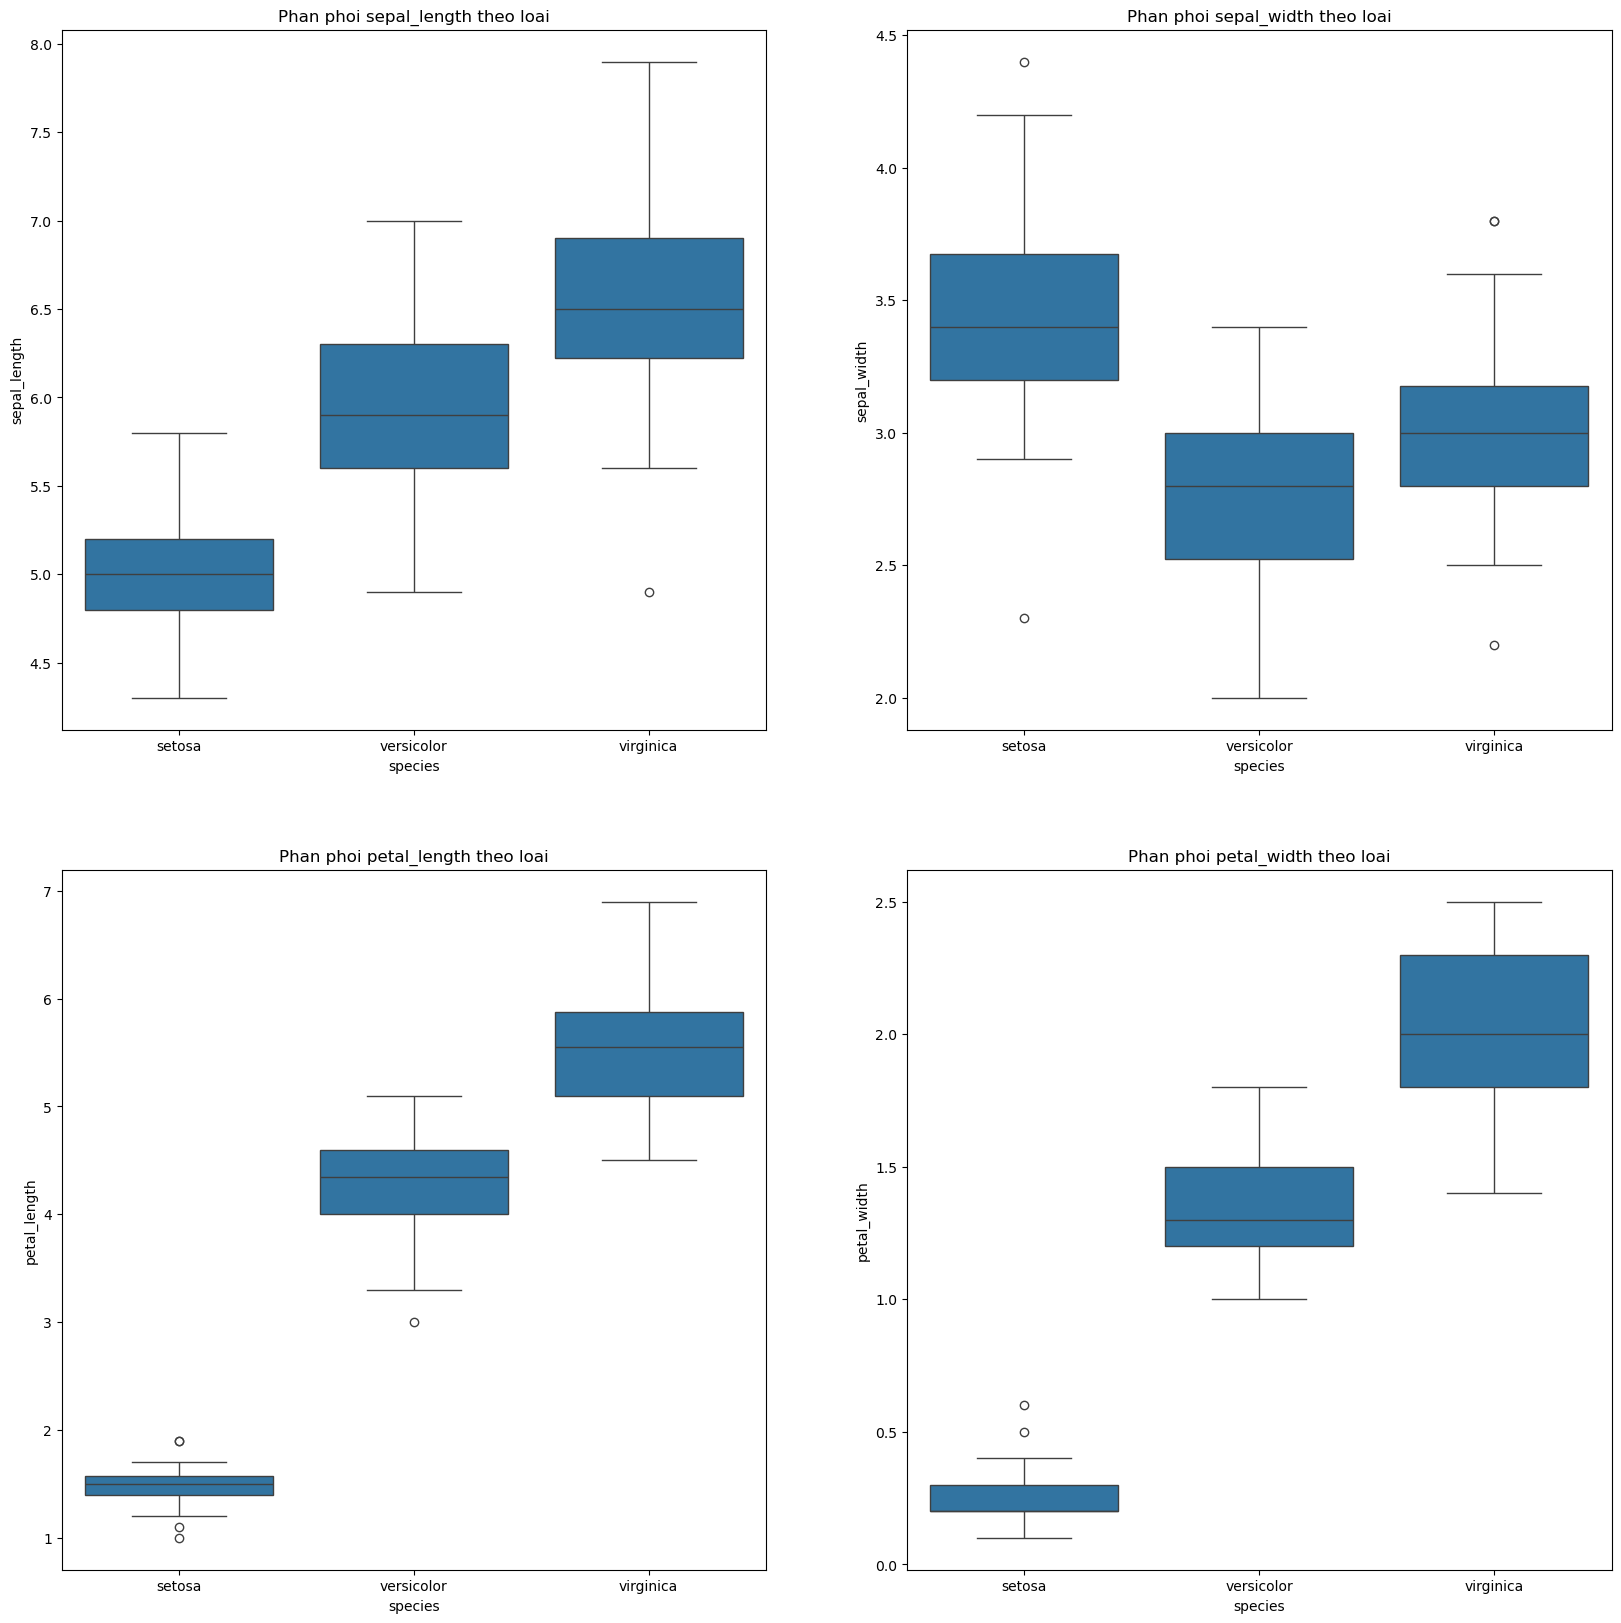

In [50]:
fig, ax = plt.subplots(2, 2, figsize = (20, 20))
ax = ax.flatten()
for i, col in enumerate(df.select_dtypes(include = ['number']).columns):
    sns.boxplot(data = df, x = 'species', y = col, ax = ax[i])
    ax[i].set_title(f'Phan phoi {col} theo loai')

3.

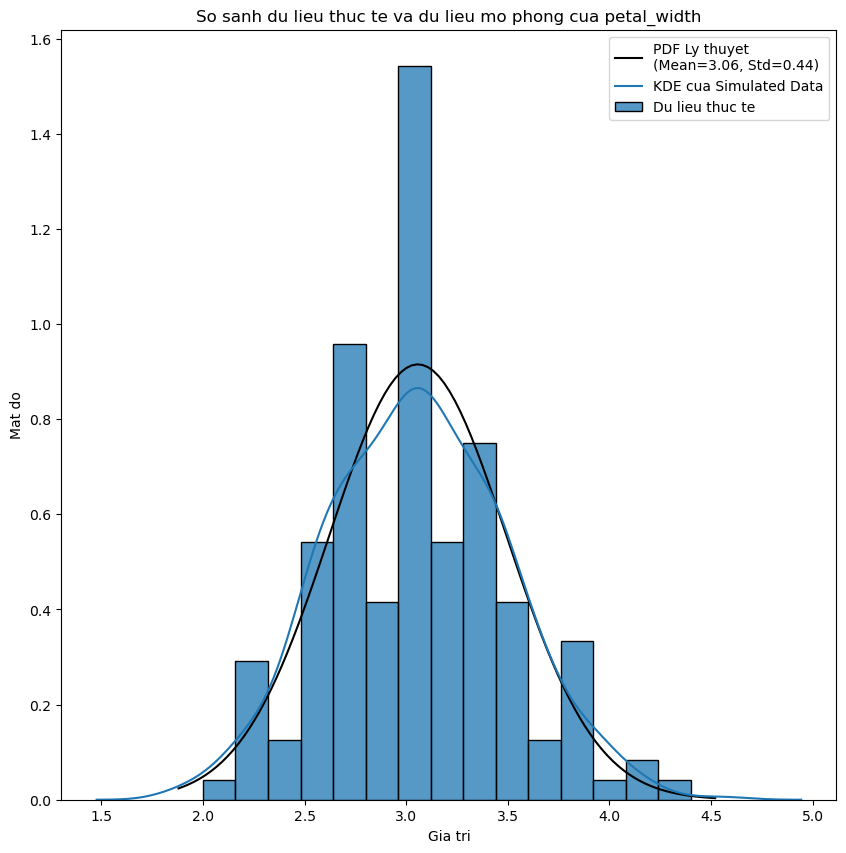

In [51]:
real_data = df['sepal_width']
mean_val = real_data.mean()
std_val = real_data.std()

simulate_data = np.random.normal(loc = mean_val, scale = std_val, size = 1000)

plt.figure(figsize = (10, 10))
sns.histplot(data = real_data, stat = 'density', bins = 15, label = 'Du lieu thuc te')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

coefficient = 1 / (std_val * np.sqrt(2 * np.pi))
exponent = np.exp(-0.5 * ((x - mean_val) / std_val)**2) 
pdf_line = coefficient * exponent

# Ve PDF
plt.plot(x, pdf_line, 'k', label=f'PDF Ly thuyet\n(Mean={mean_val:.2f}, Std={std_val:.2f})')

# Bo sung KDE
sns.kdeplot(simulate_data, label='KDE cua Simulated Data')

plt.title(f'So sanh du lieu thuc te va du lieu mo phong cua {col}')
plt.xlabel('Gia tri')
plt.ylabel('Mat do')
plt.legend()
plt.show()

- Thấy rằng đường PDF rất sát với các cột Histogram.
- Đỉnh đồ thị khớp với vị trí dữ liệu tập trung nhiều nhất trên biểu đồ.
- Giá trị giảm dần về hai bên.

-> Biến petal_with tuân theo phân phối chuẩn.

# 3 Phân tích đa biến và tương quan.

1.

In [52]:
df_numberic = df.select_dtypes(include = ['number'])

cov = df_numberic.cov()
print('Covariance matrix: \n', cov, '\n')

corr = df_numberic.corr()
print('Correlation Matrix: \n', corr)

Covariance matrix: 
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006 

Correlation Matrix: 
               sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


2.

<Axes: >

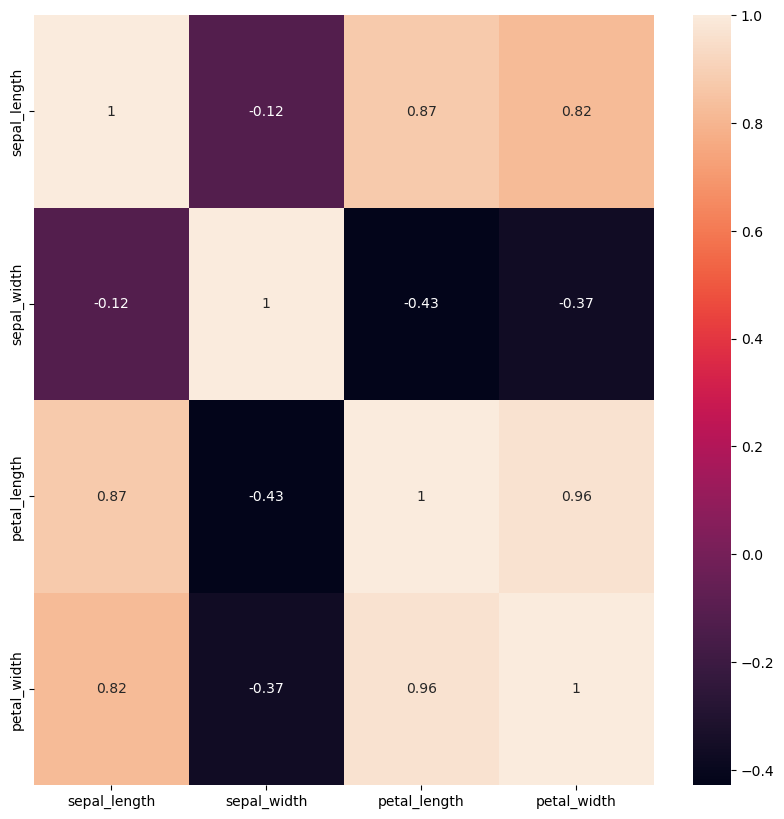

In [53]:
plt.figure(figsize = (10, 10))

sns.heatmap(corr, annot = True )

- Các cặp biến tương quan mạnh nhất là: (petal_length, petal_width) là 0.96, (sepal_length, petal_length) là 0.87, (sepal_length, petal_width) là 0.82 -> cánh hoa càng dài thì sẽ càng rộng và đài hoa càng dài thì cánh hoa sẽ càng dài và rộng.

- Có dấu hiệu đa cộng tuyến. Thấy rằng petal_length và petal_width có tương quan lên tới 0.96, hai biến này cũng cộng tuyến với sepal_length.

3

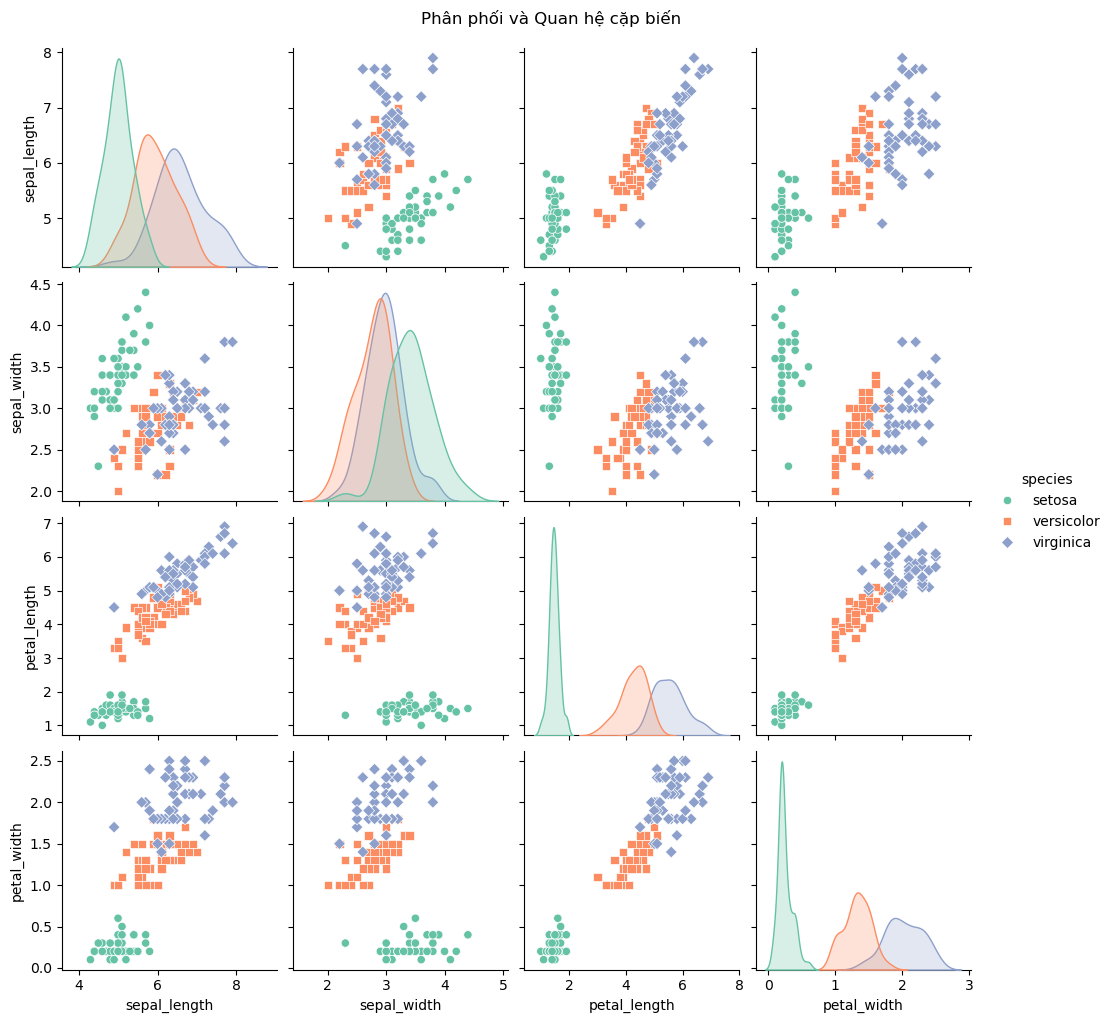

In [54]:
pair_plot = sns.pairplot(df, hue='species', palette='Set2', markers=["o", "s", "D"])
pair_plot.fig.suptitle("Phân phối và Quan hệ cặp biến", y=1.02)
plt.show()

- Ở những vùng liên quan đến petal thì loại setosa luôn cụm lại ở vùng riêng biệt so với hai loại còn lại. Từ đây ta có thể suy được giới hạn chiều dài, chiều rộng tương đối cho sepal của setosa.   
- Ở biểu đồ petal_length và petal_width thấy rằng các điểm dữ liệu sắp trên một đường chéo (ta liên hệ tới heatmap của hai biến này là 0.96)
- Ở chiều dài và chiều rộng của sepal, các điểm dữ liệu của versicolor và virginica trộn lẫn vào nhau.

# 4. Xác suất và Định lý Bayes

1

In [55]:
P_B = 0.01
P_pos_givenPosB = 0.99
P_pos_givenNegB = 0.05

P_pos = P_pos_givenNegB * (1 - P_B) + P_pos_givenPosB * P_B
P_B_givenPos = (P_pos_givenPosB * P_B) / P_pos
print(f'Xac suat mac benh khi duong xet nghiem duong tinh la P(B|+) = {P_B_givenPos:.4f}')

Xac suat mac benh khi duong xet nghiem duong tinh la P(B|+) = 0.1667


2

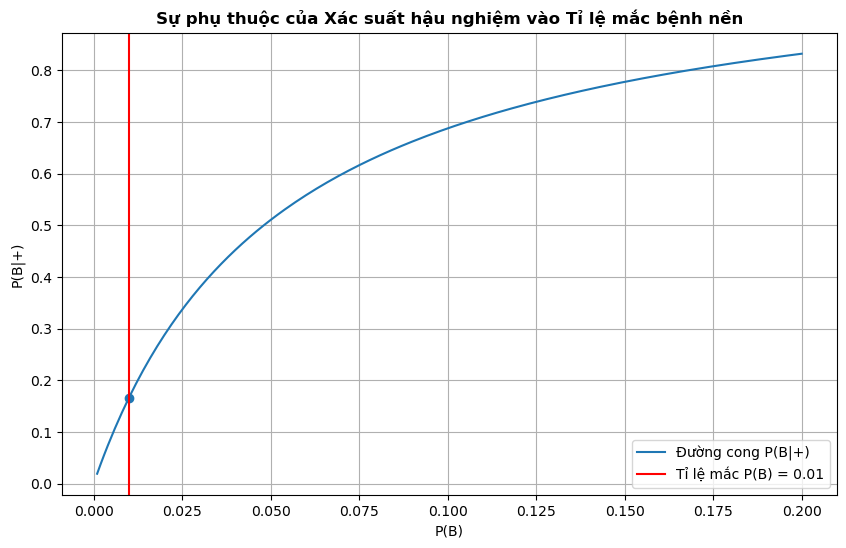

In [57]:
P_B_array = np.linspace(0.001, 0.2, 200)
P_pos_array = P_pos_givenPosB * P_B_array + P_pos_givenNegB * (1 - P_B_array)
P_B_given_pos_array = (P_pos_givenPosB * P_B_array) / P_pos_array

plt.figure(figsize=(10, 6))
plt.plot(P_B_array, P_B_given_pos_array, label='Đường cong P(B|+)')

plt.axvline(x=0.01, color = 'red', label='Tỉ lệ mắc P(B) = 0.01')
plt.scatter([0.01], [P_B_givenPos])

plt.title("Sự phụ thuộc của Xác suất hậu nghiệm vào Tỉ lệ mắc bệnh nền", fontweight='bold')
plt.xlabel("P(B)")
plt.ylabel("P(B|+)")
plt.legend()
plt.grid(True)
plt.show()

Giả sử 

3

In [ ]:

keywords_prob = {
    "khuyến mãi" : (0.8, 0.2),
    "trúng thướng":(0.9, 0.1),
    "lịch họp" : (0.05, 0.8),
    'báo cáo' : (0.1, 0.9)
}

def predict_spam(email_text): 
    words = email_text.split()
    
    p_spam_given_words = 0.4
    p_ham_given_words  = 0.6
    
    for word in words: 
        if word in keywords_prob: 
            p_word_spam, p_word_ham = keywords_prob[word]
            
            p_spam_given_words *= p_word_spam
            p_ham_given_words *= p_word_ham
            
    # Tính xác suất toàn phần P(W) (Mẫu số)
    p_total = p_spam_given_words + p_ham_given_words
    
    # Tính xác suất hậu nghiệm P(Spam | W)
    final_prob = p_spam_given_words / p_total if p_total > 0 else 0
    return final_prob

# ==========================================
# 3. THỬ NGHIỆM VỚI 3 EMAIL VÍ DỤ
# ==========================================
emails = [
    "khuyến_mãi trúng_thưởng",              # Email 1: Rõ ràng là Spam
    "họp báo_cáo",                          # Email 2: Rõ ràng là công việc (Ham)
    "khuyến_mãi họp báo_cáo trúng_thưởng"   # Email 3: Trộn lẫn từ khóa
]

print("--- KẾT QUẢ BỘ LỌC SPAM NAIVE BAYES ---")
for i, email in enumerate(emails, 1):
    prob = predict_spam(email)
    label = "SPAM 🔴" if prob > 0.5 else "HAM 🟢"
    print(f"Email {i} ['{email}']: {prob:.4f} ({prob*100:.2f}%) --> Kết luận: {label}")